# **Experiment 1:** 
To develop a program to simulate and analyze the characteristics of common communication noises.

## **Objective:**
To write a program that analyzes the effect of communication noise, specifically focusing on **Gaussian noise**, **Impulse noise**, **Thermal noise**, and **Random noise**, and understand how they affect the quality of transmitted signals.

## **Theory:**
In communication systems, noise refers to any unwanted signal that interferes with the transmission of data. Common types of noise include:
- **Gaussian Noise**: Random noise with a normal distribution, often used to model thermal noise in communication channels.
- **Impulse Noise**: Sudden spikes or impulses that can significantly degrade signal quality, often due to faulty equipment or external interferences.
- **Thermal Noise**: Noise generated due to the random motion of electrons in conductors. It is always present in electronic systems and is usually modeled as Gaussian noise.
- **Random Noise**: A type of noise that consists of unpredictable fluctuations and can vary in distribution and intensity.

Noise generally degrades the quality of a transmitted signal. The **Signal-to-Noise Ratio (SNR)** is a key parameter used to measure how much noise is present in a signal. Higher SNR means better signal quality.

## **Algorithm:**
1. **Generate a clean signal**: A simple sine wave is chosen as the clean signal.
2. **Add Gaussian noise**: Generate Gaussian noise with a specified mean and variance and add it to the clean signal.
3. **Add Impulse noise**: Introduce random impulses at random intervals in the signal.
4. **Add Thermal noise**: Introduce thermal noise using a low-variance Gaussian distribution.
5. **Add Random noise**: Introduce random noise using uniformly distributed random values.
6. **Analyze the noisy signal**: Visualize the clean and noisy signals to observe the effects of each type of noise.
7. **Compute Signal-to-Noise Ratio (SNR)**: Calculate the SNR for each noise type to quantify the impact of noise.

## **Code:**

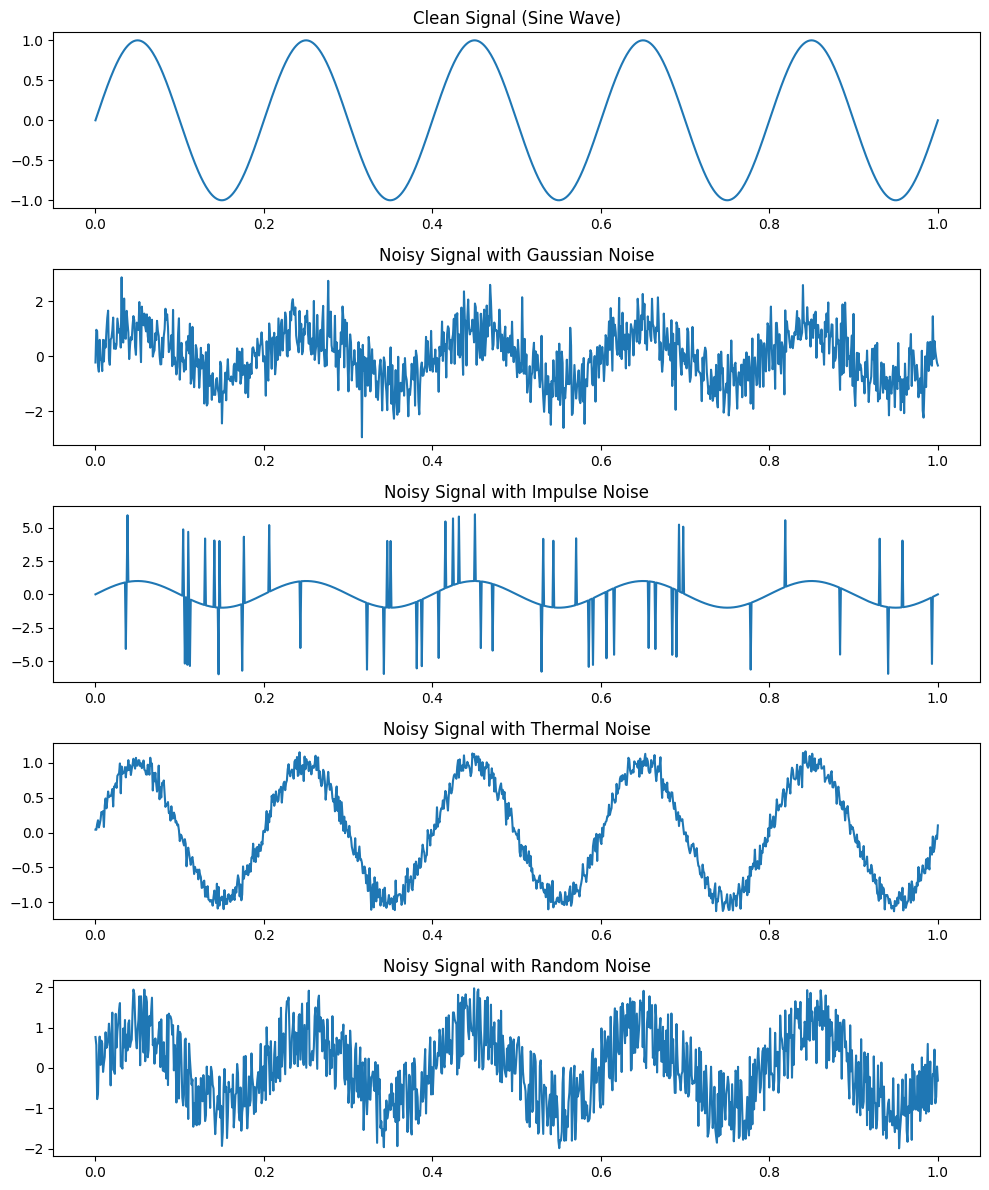

SNR Gaussian: 0.28 dB
SNR Impulse: -3.89 dB
SNR Thermal: 17.01 dB
SNR Random: 1.63 dB


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a clean signal (sine wave)
fs = 1000
t = np.linspace(0, 1, fs)
freq = 5
clean_signal = np.sin(2 * np.pi * freq * t)

# 1. Gaussian Noise
mean = 0
variance = 0.5
gaussian_noise = np.random.normal(mean, np.sqrt(variance), fs)
noisy_signal_gaussian = clean_signal + gaussian_noise

# 2. Impulse Noise
impulse_noise = np.zeros(fs)
impulse_positions = np.random.randint(0, fs, size=50)
impulse_noise[impulse_positions] = np.random.choice([-5, 5], size=50)
noisy_signal_impulse = clean_signal + impulse_noise

# 3. Thermal Noise
thermal_noise = np.random.normal(0, 0.1, fs)
noisy_signal_thermal = clean_signal + thermal_noise

# 4. Random Noise
random_noise = np.random.uniform(-1, 1, fs)
noisy_signal_random = clean_signal + random_noise

# Plot
plt.figure(figsize=(10, 12))

plt.subplot(5, 1, 1)
plt.plot(t, clean_signal)
plt.title("Clean Signal (Sine Wave)")

plt.subplot(5, 1, 2)
plt.plot(t, noisy_signal_gaussian)
plt.title("Noisy Signal with Gaussian Noise")

plt.subplot(5, 1, 3)
plt.plot(t, noisy_signal_impulse)
plt.title("Noisy Signal with Impulse Noise")

plt.subplot(5, 1, 4)
plt.plot(t, noisy_signal_thermal)
plt.title("Noisy Signal with Thermal Noise")

plt.subplot(5, 1, 5)
plt.plot(t, noisy_signal_random)
plt.title("Noisy Signal with Random Noise")

plt.tight_layout()
plt.show()

# SNR
def snr(signal, noise):
    return 10 * np.log10(np.var(signal) / np.var(noise))

print(f"SNR Gaussian: {snr(clean_signal, gaussian_noise):.2f} dB")
print(f"SNR Impulse: {snr(clean_signal, impulse_noise):.2f} dB")
print(f"SNR Thermal: {snr(clean_signal, thermal_noise):.2f} dB")
print(f"SNR Random: {snr(clean_signal, random_noise):.2f} dB")